Fruits Detection

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d moltean/fruits
!ls fruit36/fruits-360_original-size/fruits-360-original-size/Training/
!ls fruit36/fruits-360_original-size/fruits-360-original-size/Validation/


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.14G/6.14G [00:37<00:00, 175MB/s]

ls: cannot access 'fruit36/fruits-360_original-size/fruits-360-original-size/Training/': No such file or directory
ls: cannot access 'fruit36/fruits-360_original-size/fruits-360-original-size/Validation/': No such file or directory


In [ ]:
!unzip -q fruits.zip -d fruits_data

In [ ]:
# /content/fruits_data/fruits-360_100x100/fruits-360/Training
# /content/fruits_data/fruits-360_100x100/fruits-360/Test

In [ ]:
!ls fruits_data/fruits-360_100x100/fruits-360/

LICENSE  README.md  Test  Training


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [ ]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
train_dir = 'fruits_data/fruits-360_100x100/fruits-360/Training/'
val_dir = 'fruits_data/fruits-360_100x100/fruits-360/Test/'

In [ ]:
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
train_data = train_gen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_data = val_gen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

Found 137221 images belonging to 260 classes.
Found 45724 images belonging to 260 classes.


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


In [ ]:
history = model.fit(train_data,
                    epochs = 5,
                    validation_data = val_data)

Epoch 1/5
4289/4289 ━━━━━━━━━━━━━━━━━━━━ 3044s 709ms/step - accuracy: 0.8351 - loss: 0.6113 - val_accuracy: 0.9431 - val_loss: 0.5116
Epoch 2/5
 871/4289 ━━━━━━━━━━━━━━━━━━━━ 36:17 637ms/step - accuracy: 0.9486 - loss: 0.1422

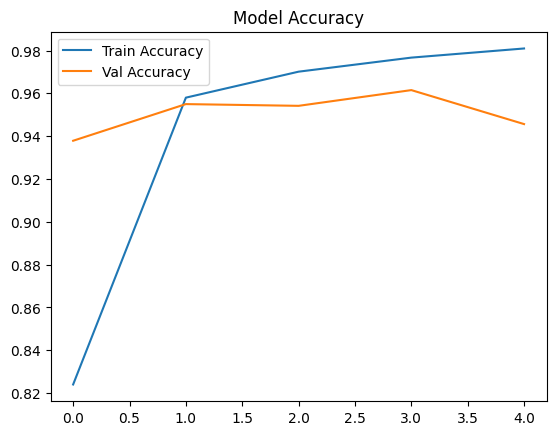

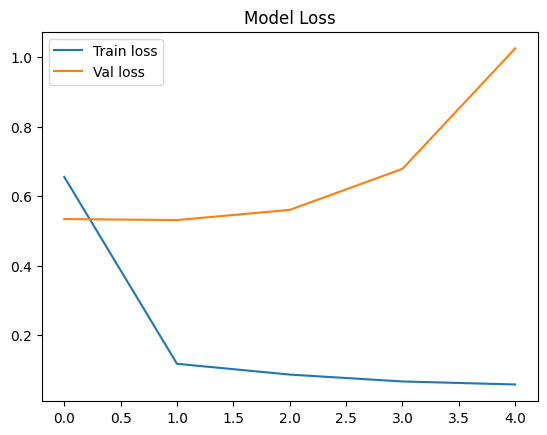

In [ ]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'], label = 'Val loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving r0_100_100.jpg to r0_100_100.jpg


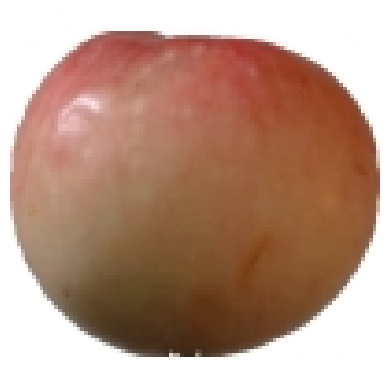

In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

image_path = list(uploaded.keys())[0]
image = load_img(image_path, target_size=IMG_SIZE)
plt.imshow(image)
plt.axis('off')
plt.show()
image = img_to_array(image) / 255.0
image = np.expand_dims(image, axis=0)

In [ ]:
pred = model.predict(image)
pred_class_index = np.argmax(pred)
pred_class_label = list(train_data.class_indices.keys())[pred_class_index]
print("Predicted class :", pred_class_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 976ms/step
Predicted class : Apple 10
